In [1]:
# Pull the refinement histories (sparse checkout; ~6 pickles). Idempotent.
# Works on Colab (/content) and locally. Skips if already cloned.
import os
if not os.path.isdir("LLM4BEAR"):
    !git clone --depth 1 --filter=blob:none --sparse https://github.com/anon5159753/LLM4BEAR.git
    !cd LLM4BEAR && git sparse-checkout set "2_Bundle Refinement"
else:
    print("LLM4BEAR already present")

Cloning into 'LLM4BEAR'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 81 (delta 10), reused 77 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 44.21 KiB | 1.64 MiB/s, done.
Resolving deltas: 100% (10/10), done.
remote: Enumerating objects: 1, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 1 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (1/1), 9.97 KiB | 9.97 MiB/s, done.
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 80 (delta 25), reused 80 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 61.82 MiB | 15.76 MiB/s, done.
Resolving deltas: 100% (25/25), done.
Updating files: 100% (155/155), done.


In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

DOMAINS      = ["electronic", "clothing", "food"]
CANONICAL    = "no_graph_help"      # canonical full-T=20 run
NO_EVALUATOR = "no_evaluator_help"  # "w/o eval. feedback" ablation
TAU          = 4                    # high-quality threshold on worst-criterion score
T_CHOICE     = 10                   # the recommended iteration limit we are justifying

HISTORY_DIR = os.path.join("LLM4BEAR", "2_Bundle Refinement", "historic_bundle_refinement")

def history_path(domain, variant):
    run = f"complete_{domain}_{variant}_run"
    return os.path.join(HISTORY_DIR, f"historical_bundle_changes_{domain}_{run}.pkl")

def load_history(domain, variant):
    # Each pickle -> 6 parallel lists indexed [iteration][bundle]:
    # intents, bundle_items, bundle_indices, scores, min_scores, flags
    with open(history_path(domain, variant), "rb") as f:
        return pickle.load(f)

def per_iteration_series(bundle_items, scores, min_scores, flags, tau=TAU):
    T = len(flags); l = len(flags[0])
    n_complete     = np.array([l - int(np.sum(flags[t])) for t in range(T)], float)
    n_complete_tau = np.array([int(np.sum(np.asarray(min_scores[t]) >= tau)) for t in range(T)], float)
    mean_size      = np.array([float(np.mean([len(b) for b in bundle_items[t]])) for t in range(T)])
    return {
        "iterations": np.arange(T), "n_bundles": l,
        "n_complete": n_complete, "complete_rate": n_complete / l,
        "complete_rate_tau": n_complete_tau / l,
        "mean_size": mean_size,
        "mean_min_score": np.array([float(np.mean(min_scores[t])) for t in range(T)]),
    }

def flag_tau_agreement(min_scores, flags, tau=TAU):
    agree = total = 0
    for t in range(len(flags)):
        fl = np.asarray(flags[t], bool); ms = np.asarray(min_scores[t])
        agree += int(np.sum((~fl) == (ms >= tau))); total += len(fl)
    return agree / total

# Load every needed series once.
canonical, ablation, agreements = {}, {}, {}
for d in DOMAINS:
    _, bi, _, sc, ms, fl = load_history(d, CANONICAL)
    canonical[d]  = per_iteration_series(bi, sc, ms, fl)
    agreements[d] = flag_tau_agreement(ms, fl)
    _, bi2, _, sc2, ms2, fl2 = load_history(d, NO_EVALUATOR)
    ablation[d]   = per_iteration_series(bi2, sc2, ms2, fl2)
print("Loaded:", {d: (len(canonical[d]['iterations']), len(ablation[d]['iterations'])) for d in DOMAINS})

Loaded: {'electronic': (21, 11), 'clothing': (21, 11), 'food': (21, 11)}


In [3]:
# Shared style.
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 11,
    "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9.5,
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
})
DOMAIN_LABEL = {"electronic": "Electronic", "clothing": "Clothing", "food": "Food"}
DOMAIN_COLOR = {"electronic": "#0072B2", "clothing": "#D55E00", "food": "#009E73"}
CANON_STYLE  = dict(linestyle="-",  linewidth=2.2, marker="o", markersize=4)
ABLAT_STYLE  = dict(linestyle="--", linewidth=2.2, marker="s", markersize=4)
os.makedirs("figures", exist_ok=True)

def t_marker(ax, label=True):
    ax.axvline(T_CHOICE, color="0.35", linestyle=":", linewidth=1.5, zorder=0)
    if label:
        ax.annotate(f"T = {T_CHOICE}", xy=(T_CHOICE, 0.02),
                    xycoords=("data", "axes fraction"), xytext=(4, 0),
                    textcoords="offset points", va="bottom", ha="left",
                    fontsize=9, color="0.35")

### Figure 1 — completion rate vs. iteration (LLM4BEAR)

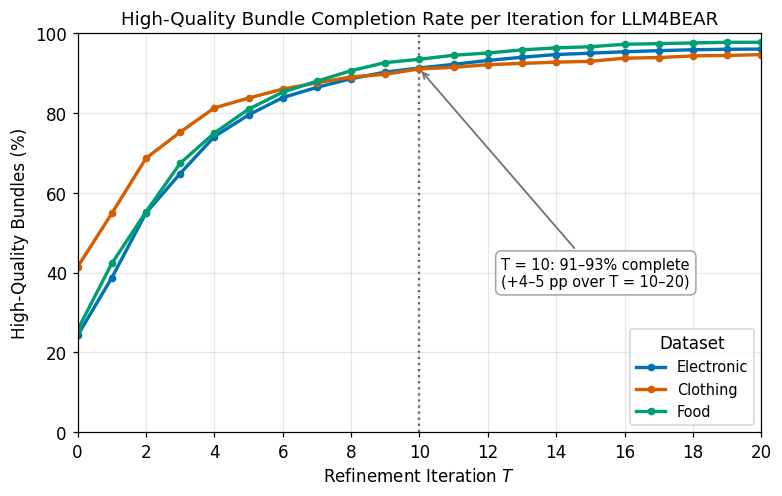

In [4]:
fig, ax = plt.subplots(figsize=(7.0, 4.4), constrained_layout=True)
for d in DOMAINS:
    s = canonical[d]
    ax.plot(s["iterations"], 100 * s["complete_rate"],
            color=DOMAIN_COLOR[d], label=DOMAIN_LABEL[d], **CANON_STYLE)

r10   = [100 * canonical[d]["complete_rate"][T_CHOICE] for d in DOMAINS]
gains = [100 * (canonical[d]["complete_rate"][20] - canonical[d]["complete_rate"][T_CHOICE]) for d in DOMAINS]
ax.annotate(f"T = 10: {min(r10):.0f}–{max(r10):.0f}% complete\n"
            f"(+{min(gains):.0f}–{max(gains):.0f} pp over T = 10–20)",
            xy=(T_CHOICE, min(r10)), xytext=(0.62, 0.44), textcoords="axes fraction",
            fontsize=9.5, ha="left", va="top",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="0.6", alpha=0.9),
            arrowprops=dict(arrowstyle="->", color="0.45", lw=1.2))
t_marker(ax, label=False)
ax.set_xlabel("Refinement Iteration $T$"); ax.set_ylabel("High-Quality Bundles (%)")
ax.set_title("High-Quality Bundle Completion Rate per Iteration for LLM4BEAR")
ax.set_xlim(0, 20); ax.set_xticks(range(0, 21, 2)); ax.set_ylim(0, 100)
ax.legend(title="Dataset", loc="lower right")
for ext in ("pdf", "png"):
    fig.savefig(f"figures/fig_iteration_T.{ext}", bbox_inches="tight")
plt.show()

### Figure 2 — evaluator-feedback ablation (per dataset)

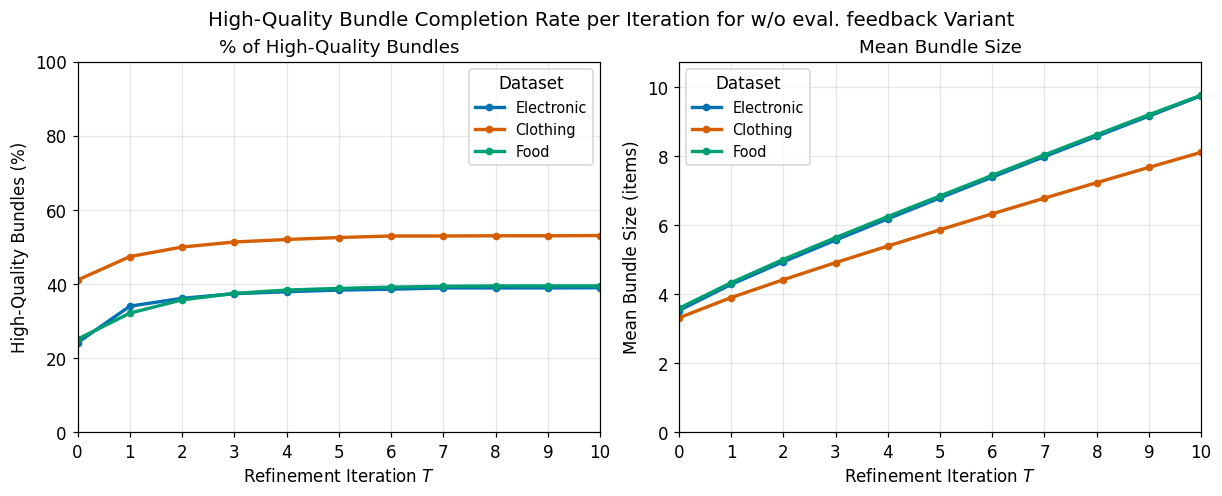

In [5]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(11.0, 4.4), constrained_layout=True)
for d in DOMAINS:
    s, color = ablation[d], DOMAIN_COLOR[d]
    axl.plot(s["iterations"], 100 * s["complete_rate"], color=color, label=DOMAIN_LABEL[d], **CANON_STYLE)
    axr.plot(s["iterations"], s["mean_size"],           color=color, label=DOMAIN_LABEL[d], **CANON_STYLE)
max_t = max(int(s["iterations"][-1]) for s in ablation.values())
axl.set_ylim(0, 100); axl.set_ylabel("High-Quality Bundles (%)")
axl.set_title("% of High-Quality Bundles"); axl.legend(title="Dataset", loc="best")
top = max(s["mean_size"].max() for s in ablation.values())
axr.set_ylim(0, top * 1.1); axr.set_ylabel("Mean Bundle Size (items)")
axr.set_title("Mean Bundle Size"); axr.legend(title="Dataset", loc="best")
for ax in (axl, axr):
    ax.set_xlabel("Refinement Iteration $T$"); ax.set_xlim(0, max_t); ax.set_xticks(range(0, max_t + 1))
fig.suptitle("High-Quality Bundle Completion Rate per Iteration for w/o eval. feedback Variant", fontsize=13)
for ext in ("pdf", "png"):
    fig.savefig(f"figures/fig_no_evaluator_ablation.{ext}", bbox_inches="tight")
plt.show()

In [7]:
def pct(x): return f"{100*x:5.1f}%"
print("LLM4BEAR — high-quality completion rate by iteration")
print(f"{'dataset':11s} {'T=0':>7s} {'T=5':>7s} {'T=10':>7s} {'T=20':>7s} {'gain 10>20':>11s} {'flag~tau':>9s}")
for d in DOMAINS:
    r = canonical[d]["complete_rate"]
    print(f"{d:11s} {pct(r[0])} {pct(r[5])} {pct(r[10])} {pct(r[20])} {100*(r[20]-r[10]):9.1f}pp {agreements[d]:8.1%}")
print("\nMean bundle size (items) — LLM4BEAR vs. w/o evaluator feedback")
print(f"{'dataset':11s} {'canon T0':>9s} {'canon T10':>10s} {'canon T20':>10s}  {'abl T0':>7s} {'abl T10':>8s}")
for d in DOMAINS:
    c, a = canonical[d]["mean_size"], ablation[d]["mean_size"]
    print(f"{d:11s} {c[0]:9.2f} {c[10]:10.2f} {c[20]:10.2f}  {a[0]:7.2f} {a[-1]:8.2f}")
print("\nw/o evaluator feedback — high-quality completion rate (barely improves)")
print(f"{'dataset':11s} {'T=0':>7s} {'T=1':>7s} {'T=10':>7s}")
for d in DOMAINS:
    r = ablation[d]["complete_rate"]
    print(f"{d:11s} {pct(r[0])} {pct(r[1])} {pct(r[-1])}")

LLM4BEAR — high-quality completion rate by iteration
dataset         T=0     T=5    T=10    T=20  gain 10>20  flag~tau
electronic   24.3%  79.5%  91.3%  96.1%       4.7pp    98.5%
clothing     41.5%  83.8%  91.1%  94.7%       3.6pp    97.9%
food         25.7%  81.0%  93.5%  97.8%       4.3pp    97.1%

Mean bundle size (items) — LLM4BEAR vs. w/o evaluator feedback
dataset      canon T0  canon T10  canon T20   abl T0  abl T10
electronic       3.52       2.82       2.84     3.52     9.75
clothing         3.31       2.63       2.65     3.31     8.11
food             3.58       3.22       3.23     3.58     9.76

w/o evaluator feedback — high-quality completion rate (barely improves)
dataset         T=0     T=1    T=10
electronic   24.2%  34.0%  39.0%
clothing     41.0%  47.4%  53.0%
food         25.1%  32.1%  39.5%
